1. Fetch the artifact we just created (sample.csv) from W&B and read it with pandas:

In [116]:
!python -m pip show wandb

Name: wandb
Version: 0.28.1
Summary: A CLI and library for interacting with the Weights & Biases API.
Home-page: 
Author: 
Author-email: Weights & Biases <support@wandb.com>
License: MIT License
        
        Copyright (c) 2021 Weights and Biases, Inc.
        
        Permission is hereby granted, free of charge, to any person obtaining a copy
        of this software and associated documentation files (the "Software"), to deal
        in the Software without restriction, including without limitation the rights
        to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
        copies of the Software, and to permit persons to whom the Software is
        furnished to do so, subject to the following conditions:
        
        The above copyright notice and this permission notice shall be included in all
        copies or substantial portions of the Software.
        
        THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
        IM

In [117]:
!python -m pip install wandb

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [118]:
!python -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [119]:
!python -m pip install matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [120]:
import wandb
import pandas as pd
# Note that we use save_code=True in the call to wandb.init so the notebook is uploaded and versioned by W&B
run = wandb.init(project="nyc_airbnb", group="eda", save_code=True)
local_path = wandb.use_artifact("sample.csv:latest").file()
df = pd.read_csv(local_path)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


2. Explore the data in df

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  int64  
 1   name                            19993 non-null  object 
 2   host_id                         20000 non-null  int64  
 3   host_name                       19992 non-null  object 
 4   neighbourhood_group             20000 non-null  object 
 5   neighbourhood                   20000 non-null  object 
 6   latitude                        20000 non-null  float64
 7   longitude                       20000 non-null  float64
 8   room_type                       20000 non-null  object 
 9   price                           20000 non-null  int64  
 10  minimum_nights                  20000 non-null  int64  
 11  number_of_reviews               20000 non-null  int64  
 12  last_review                     

In [122]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,15877.000000,20000.000000,20000.000000
mean,1.892380e+07,6.746034e+07,40.728455,-73.952125,153.269050,6.992100,23.274100,1.377446,6.955450,112.901200
std,1.101223e+07,7.857936e+07,0.054755,0.046559,243.325609,21.645449,44.927793,1.683006,32.433831,131.762226
min,2.539000e+03,2.571000e+03,40.508730,-74.239140,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.393540e+06,7.853718e+06,40.689420,-73.983030,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.952117e+07,3.111431e+07,40.722730,-73.955640,105.000000,2.000000,5.000000,0.720000,1.000000,44.000000
75%,2.912936e+07,1.068426e+08,40.762990,-73.936380,175.000000,5.000000,23.000000,2.010000,2.000000,229.000000
max,3.648561e+07,2.742733e+08,40.913060,-73.717950,10000.000000,1250.000000,607.000000,27.950000,327.000000,365.000000


In [123]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9138664,Private Lg Room 15 min to Manhattan,47594947,Iris,Queens,Sunnyside,40.74271,-73.92493,Private room,74,2,6,2019-05-26,0.13,1,5
1,31444015,TIME SQUARE CHARMING ONE BED IN HELL'S KITCHEN...,8523790,Johlex,Manhattan,Hell's Kitchen,40.76682,-73.98878,Entire home/apt,170,3,0,NaN,NaN,1,188
2,8741020,Voted #1 Location Quintessential 1BR W Village...,45854238,John,Manhattan,West Village,40.73631,-74.00611,Entire home/apt,245,3,51,2018-09-19,1.12,1,0
3,34602077,Spacious 1 bedroom apartment 15min from Manhattan,261055465,Regan,Queens,Astoria,40.76424,-73.92351,Entire home/apt,125,3,1,2019-05-24,0.65,1,13
4,23203149,Big beautiful bedroom in huge Bushwick apartment,143460,Megan,Brooklyn,Bushwick,40.69839,-73.92044,Private room,65,2,8,2019-06-23,0.52,2,8


In [124]:
df_nyc = df.copy()

In [125]:
df.isna().sum()

id                                   0
name                                 7
host_id                              0
host_name                            8
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       4123
reviews_per_month                 4123
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [126]:
df.isnull().sum().sum()

np.int64(8261)

In [127]:
df.shape

(20000, 16)

In [128]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [129]:
df_missing = df_nyc.isnull().sum().sort_values(ascending = False)
df_missing_percent = (df_missing/len(df_nyc) * 100)
print("MISSING %")  
print(f"{df_missing_percent}:.2f%")


MISSING %
last_review                       20.615
reviews_per_month                 20.615
host_name                          0.040
name                               0.035
neighbourhood_group                0.000
neighbourhood                      0.000
id                                 0.000
host_id                            0.000
longitude                          0.000
latitude                           0.000
room_type                          0.000
price                              0.000
number_of_reviews                  0.000
minimum_nights                     0.000
calculated_host_listings_count     0.000
availability_365                   0.000
dtype: float64:.2f%


In [130]:
df_nyc['price'].skew()

np.float64(18.30468960298398)

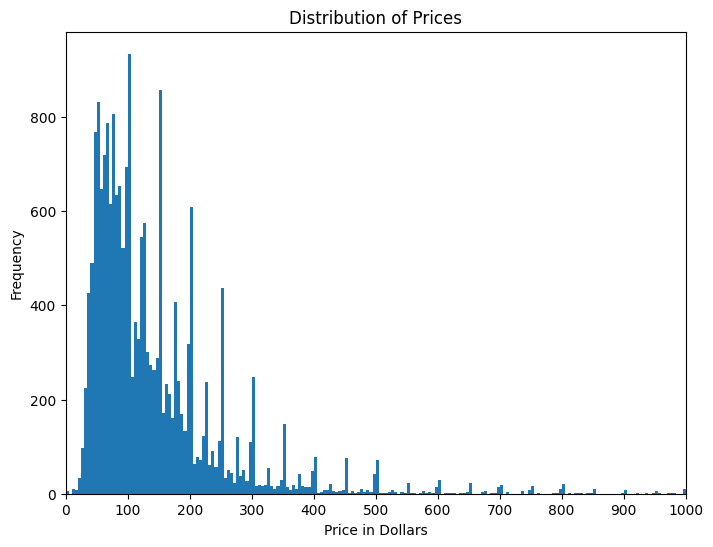

In [131]:
plt.figure(figsize= (8,6))
plt.hist(df_nyc['price'], bins = 2000)
plt.title('Distribution of Prices')
plt.xlabel('Price in Dollars')
plt.xlim (0,1000)
plt.xticks(range(0, 1001, 100))
plt.ylabel('Frequency')
plt.show()

3. What do you notice in the data? Look around and see what you can find.

> For example, there are missing values in a few columns and the column `last_review` is a date but it is in string format. Look also at the `price` column, and note the outliers. There are some zeros and some very high prices. After talking to your stakeholders, you decide to consider from a minimum of `$10` to a maximum of `$350` per night.

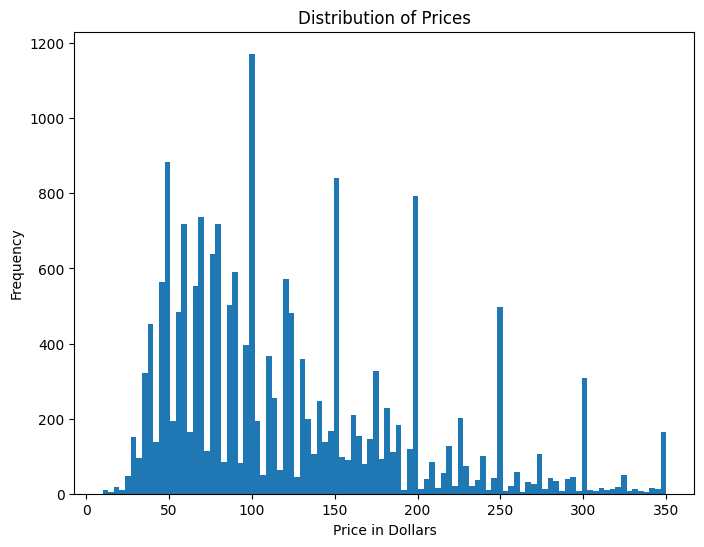

In [132]:
plt.figure(figsize= (8,6))
plt.hist(df_nyc[df_nyc['price'].between (10,350)]['price'], bins = 100)
plt.title("Distribution of Prices")
plt.xlabel("Price in Dollars")
plt.ylabel("Frequency")
plt.show()

In [133]:
df_nyc[df_nyc['price'].between (10,350)]['price'].skew()

np.float64(1.0270244109622166)

In [134]:
df_nyc_filtered = df_nyc[df_nyc['price'].between(10,350)]['price']

In [135]:
print("Full Data Set Median Price: ", round(df_nyc['price'].median(),2))
print("Full Data Set Mean Price: ", round(df_nyc['price'].mean(),2))

Full Data Set Median Price:  105.0
Full Data Set Mean Price:  153.27


In [136]:
print("Filtered Data Set Median Price: ", round((df_nyc_filtered).median(), 2))
print("Filtered Data Set Mean Price: ", round((df_nyc_filtered).mean(), 2))

Filtered Data Set Median Price:  100.0
Filtered Data Set Mean Price:  122.34


Original skew measure for complete data set = 18.03 Extremely right skewed due to a smaller number of more expensive properties. The average price is 45% higher than the median price supporting a right skewed distribution. 
When only the properties between $10 and $350 are filtered into a set, the average price is only 22% higher than the median price. So, the filtered data set is still skewed right since the skew measure = 1.03, but not so severely skewed right. 

4. Fix some of the little problems we have found in the data with the following code:

In [137]:
# Drop outliers
min_price = 10
max_price = 350
idx = df_nyc['price'].between(min_price, max_price)
df_nyc_filtered2 = df_nyc[idx].copy()
# Convert last_review to datetime
df_nyc_filtered2['last_review'] = pd.to_datetime(df_nyc['last_review'])

Note how we did not impute missing values. We will do that in the inference pipeline, so we will be able to handle missing values also in production.

5. Check with df.info() that all obvious problems have been solved

In [138]:
df_nyc_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19001 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19001 non-null  int64         
 1   name                            18994 non-null  object        
 2   host_id                         19001 non-null  int64         
 3   host_name                       18993 non-null  object        
 4   neighbourhood_group             19001 non-null  object        
 5   neighbourhood                   19001 non-null  object        
 6   latitude                        19001 non-null  float64       
 7   longitude                       19001 non-null  float64       
 8   room_type                       19001 non-null  object        
 9   price                           19001 non-null  int64         
 10  minimum_nights                  19001 non-null  int64         
 11  number_

In [139]:
print("Min Price: ",df_nyc_filtered2['price'].min())
print("Max Price: ",df_nyc_filtered2['price'].max())

Min Price:  10
Max Price:  350


6. Terminate the run by running `run.finish()`

In [140]:
run.finish()

7. Save the notebook.